In [214]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import yfinance as yf

## テーマETFの戦略設計
テーマETFの価格形成は以下の要因と仮定
$$R_{i,t}=\beta_iF_t+\theta_i Theme_i+\epsilon_{i,t}$$
$F_T$: 市場ファクター、$T_t$: テーマ固有トレンド、$\theta_i$: テーマ感応度

テーマトレンド検出＋ETF選択

In [215]:
CONFIG = {
    # Data scope
    'start_date': '2010-07-23',
    'end_date': None,
    'tickers': [
        'AGNG','AIQ','AQWA','BITS','BKCH','BOTZ','BUG','CHPX','CLOU','CTEC','DRIV','DTCR',
        'EBIZ','FINX','GNOM','HEAL','HERO','HYDR','IPAV','KROP','LIT','MILN','PAVE','RNRG',
        'SHLD','SNSR','SOCL','ZAP'
    ],
    #'tickers': [
    #    "XLB","XLE","XLF","XLI","XLK","XLP","XLU","XLV","XLY",
    #],
    'local_csv_path': 'data/theme_etf.csv',
    #'local_csv_path': 'data/sector_etf.csv',
    'rebalance': 'W-FRI',  # 'M' or 'W-FRI'

    'cost_bps': 10,
    'benchmark': 'EQW',

    # Factor construction (monthly meaning; converted to runtime periods)
    #'factor_method': 'pca',
    'pca_window_months': 60,
    'n_components': 8,
    #'standardize': True,
    'min_obs_per_window': 24,

    # Factor momentum (monthly meaning; converted to runtime periods)
    'factor_mom_lookbacks': [1, 12],
    'factor_mom_skip_months': 1,   # 12-1 style in monthly meaning
    'combine_weights': {1: 0.5, 12: 0.5},
    'factor_weighting': 'top_m',   # 'top_m' | 'rank' | 'sign'
    'top_m_factors': 3,
    'exclude_pcs': [1],

    # ETF mapping (monthly meaning; converted to runtime periods)
    #'etf_mapping_modes': ['loadings', 'regression'],
    'regression_window_months': 60,

    # Portfolio constraints
    'long_only': True,
    'weight_cap': None,
}

def load_data(config):
    tickers = config['tickers']
    start = pd.to_datetime(config['start_date']) if config.get('start_date') else None
    end = pd.to_datetime(config['end_date']) if config.get('end_date') else None

    raw = pd.read_csv(config['local_csv_path'], header=[0, 1], index_col=0, parse_dates=True)
    px_d = raw['Adj Close'].copy()
    vol_d = raw['Volume'].copy() if 'Volume' in raw.columns.get_level_values(0) else pd.DataFrame(index=px_d.index, columns=px_d.columns)
    
    px_d = px_d.reindex(columns=tickers)
    vol_d = vol_d.reindex(columns=tickers)
    px_d = px_d.sort_index()
    vol_d = vol_d.sort_index()

    if start is not None:
        px_d = px_d.loc[px_d.index >= start]
        vol_d = vol_d.loc[vol_d.index >= start]
    if end is not None:
        px_d = px_d.loc[px_d.index <= end]
        vol_d = vol_d.loc[vol_d.index <= end]

    return px_d, vol_d

px_d, vol_d = load_data(CONFIG)

In [216]:

missing_ratio = px_d.isna().mean().sort_values(ascending=False)
summary = pd.DataFrame({
    'missing_ratio': missing_ratio,
    'non_null_days': px_d.notna().sum(),
})

print('Data source:', 'yfinance' if CONFIG.get('use_yfinance', False) else CONFIG['local_csv_path'])
print(f'Daily date range: {px_d.index.min().date()} -> {px_d.index.max().date()}')
print(f'Ticker count: {px_d.shape[1]}')
display(summary.head(10))

px_d.tail()

Data source: data/theme_etf.csv
Daily date range: 2010-07-23 -> 2026-02-27
Ticker count: 28


,missing_ratio,non_null_days
Ticker,,
AGNG,0.371814,2465
AIQ,0.501274,1957
AQWA,0.687309,1227
BITS,0.726300,1074
BKCH,0.703874,1162
BOTZ,0.393986,2378
BUG,0.595311,1588
CHPX,0.973751,103
CLOU,0.559888,1727


Ticker,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-23,38.439999,48.529999,20.485001,53.153000,61.709999,38.580002,24.299999,60.896999,18.110001,59.659000,...,33.514999,36.112000,73.779999,41.917000,54.860001,37.345001,74.339996,39.659000,49.270000,32.860001
2026-02-24,38.341000,49.490002,20.777000,54.736000,64.849998,39.009998,24.370001,62.669998,18.559999,61.338001,...,33.756001,36.473000,75.589996,42.430000,55.650002,37.375000,74.889999,40.535000,49.139999,33.290001
2026-02-25,38.428001,50.549999,20.802999,57.162998,66.320000,39.660000,24.980000,63.900002,18.799999,61.584999,...,33.990002,36.344002,77.089996,42.840000,55.070000,37.563999,73.919998,40.921001,49.490002,33.400002
2026-02-26,37.990002,50.520000,20.893999,56.136002,65.470001,39.500000,25.690001,62.283001,19.010000,59.637001,...,33.930000,36.252998,75.769997,43.542999,55.330002,37.431999,74.339996,40.915001,49.450001,33.250000
2026-02-27,38.349998,50.259998,20.815001,53.895000,62.299999,39.020000,25.110001,61.930000,18.760000,58.603001,...,33.922001,36.794998,75.400002,43.467999,55.090000,36.955002,74.860001,40.613998,49.330002,33.349998


In [217]:
def _convert_months_to_periods(month_value, scale):
    return max(1, int(round(float(month_value) * scale)))

def resolve_runtime_params(config):
    rebalance = str(config.get('rebalance', 'M')).upper()
    if rebalance == 'M':
        rule = 'ME'
        periods_per_year = 12
        scale = 1.0
        frequency_label = 'Monthly (EOM)'
    elif rebalance.startswith('W-'):
        rule = rebalance
        periods_per_year = 52
        scale = 52.0 / 12.0
        frequency_label = f'Weekly ({rebalance})'
    else:
        raise ValueError("rebalance must be 'M' or 'W-XXX' (e.g., W-FRI, W-WED).")

    pca_window = _convert_months_to_periods(config['pca_window_months'], scale)
    reg_window = _convert_months_to_periods(config['regression_window_months'], scale)
    min_obs = _convert_months_to_periods(config['min_obs_per_window'], scale)
    skip_periods = _convert_months_to_periods(config['factor_mom_skip_months'], scale)

    lookbacks_months = [int(x) for x in config['factor_mom_lookbacks']]
    lookbacks_periods = [_convert_months_to_periods(x, scale) for x in lookbacks_months]

    # 変換後lookbackが重複する場合はweightを合算
    raw_cw = {int(k): float(v) for k, v in config['combine_weights'].items()}
    combined = {}
    for lb_month, lb_period in zip(lookbacks_months, lookbacks_periods):
        w = raw_cw.get(lb_month, 0.0)
        combined[lb_period] = combined.get(lb_period, 0.0) + w

    if sum(combined.values()) == 0:
        unique_lb = sorted(set(lookbacks_periods))
        combined = {lb: 1.0 / len(unique_lb) for lb in unique_lb}
    else:
        s = sum(combined.values())
        combined = {k: v / s for k, v in combined.items()}

    lookbacks_periods = sorted(set(lookbacks_periods))

    return {
        'rebalance': rebalance,
        'rule': rule,
        'periods_per_year': periods_per_year,
        'scale': scale,
        'frequency_label': frequency_label,
        'pca_window': pca_window,
        'reg_window': reg_window,
        'min_obs': min_obs,
        'skip_periods': skip_periods,
        'lookbacks_periods': lookbacks_periods,
        'combine_weights_periods': combined,
        'lookback_month_to_period': dict(zip(lookbacks_months, [_convert_months_to_periods(x, scale) for x in lookbacks_months])),
    }

## Daily -> Periodic (ME or W-FRI)
def to_periodic(px_d, vol_d, rule):
    px_p = px_d.resample(rule).last()
    vol_p = vol_d.resample(rule).sum(min_count=1)
    ret_p = px_p.pct_change()
    return px_p, ret_p, vol_p


RUNTIME = resolve_runtime_params(CONFIG)
px_p, ret_p, vol_p = to_periodic(px_d, vol_d, RUNTIME['rule'])


print(f"Rebalance mode: {RUNTIME['frequency_label']} (rule={RUNTIME['rule']})")
print('Timing: decide at period-end t and apply to next period return (t+1)')
print(f"Periodic range: {ret_p.index.min().date()} -> {ret_p.index.max().date()} (obs={len(ret_p)})")
print('Periodic return panel shape:', ret_p.shape)

ret_p.iloc[-5:, :8]

Rebalance mode: Weekly (W-FRI) (rule=W-FRI)
Timing: decide at period-end t and apply to next period return (t+1)
Periodic range: 2010-07-23 -> 2026-02-27 (obs=815)
Periodic return panel shape: (815, 28)


Ticker,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX
Date,,,,,,,,
2026-01-30,-0.004314,-0.010284,0.002569,-0.076999,-0.086019,-0.011914,-0.036351,0.003844
2026-02-06,0.017168,-0.036367,0.024823,-0.136989,-0.116047,0.004287,-0.059029,0.004429
2026-02-13,0.014189,-0.012580,0.021770,0.003268,0.021985,0.022946,0.035264,0.010360
2026-02-20,0.003412,0.008696,-0.012525,-0.037545,-0.053319,0.017736,-0.083184,0.014011
2026-02-27,0.003218,0.007618,0.011517,-0.008755,0.011199,0.000000,-0.017990,0.002022


In [218]:
RUNTIME

{'rebalance': 'W-FRI',
 'rule': 'W-FRI',
 'periods_per_year': 52,
 'scale': 4.333333333333333,
 'frequency_label': 'Weekly (W-FRI)',
 'pca_window': 260,
 'reg_window': 260,
 'min_obs': 104,
 'skip_periods': 4,
 'lookbacks_periods': [4, 52],
 'combine_weights_periods': {4: 0.5, 52: 0.5},
 'lookback_month_to_period': {1: 4, 12: 52}}

In [219]:
## 5) Rolling PCA factor construction

def build_rolling_pca(ret_p, runtime):
    window = runtime['pca_window']
    n_components = CONFIG['n_components']
    standardize = CONFIG.get('standardize', True)
    min_obs = runtime['min_obs']

    factor_cols = [f'F{i+1}' for i in range(n_components)]
    factor_ret = pd.DataFrame(index=ret_p.index, columns=factor_cols, dtype=float)

    loadings_by_t = {}
    elig_count = pd.Series(index=ret_p.index, dtype=float)
    eligibility_mask_by_t = {}

    prev_loadings = None

    for i, t in enumerate(ret_p.index):
        if i < window - 1:
            continue

        win = ret_p.iloc[i - window + 1 : i + 1]
        obs = win.notna().sum()
        elig = obs >= min_obs
        elig = elig.reindex(ret_p.columns).fillna(False)
        # 決定期tで観測不能なETFは投資対象外
        elig = elig & ret_p.loc[t].notna().reindex(ret_p.columns).fillna(False)

        eligibility_mask_by_t[t] = elig
        elig_count.loc[t] = int(elig.sum())

        if int(elig.sum()) < 2:
            continue

        x = win.loc[:, elig.index[elig.values]].copy()

        # 窓内のみで欠損補完（未来情報不使用）
        x = x.apply(lambda col: col.fillna(col.mean()), axis=0)
        x = x.fillna(0.0)

        if standardize:
            mu = x.mean(axis=0)
            sd = x.std(axis=0, ddof=0).replace(0.0, 1.0)
            x_std = (x - mu) / sd
        else:
            x_std = x

        k = min(n_components, x_std.shape[1], x_std.shape[0])
        if k < 1:
            continue

        pca = PCA(n_components=k, random_state=42)
        scores = pca.fit_transform(x_std.values)
        loadings = pd.DataFrame(pca.components_.T, index=x_std.columns, columns=[f'F{i+1}' for i in range(k)])

        # PCA符号の時系列整合
        if prev_loadings is not None:
            common_assets = loadings.index.intersection(prev_loadings.index)
            common_factors = loadings.columns.intersection(prev_loadings.columns)
            for fc in common_factors:
                if len(common_assets) == 0:
                    continue
                sign_anchor = float((loadings.loc[common_assets, fc] * prev_loadings.loc[common_assets, fc]).sum())
                if sign_anchor < 0:
                    loadings[fc] *= -1.0
                    col_idx = list(loadings.columns).index(fc)
                    scores[:, col_idx] *= -1.0

        prev_loadings = loadings.copy()

        f_t = pd.Series(scores[-1, :], index=loadings.columns)
        factor_ret.loc[t, f_t.index] = f_t.values
        loadings_by_t[t] = loadings

    elig_count = elig_count.fillna(0).astype(int).rename('eligible_count_pca')
    elig_count.attrs['eligibility_mask_by_t'] = eligibility_mask_by_t

    return factor_ret, loadings_by_t, elig_count

factor_ret, loadings_by_t, elig_pca_count = build_rolling_pca(ret_p, RUNTIME)

## factor_ret（因子リターン）の時系列

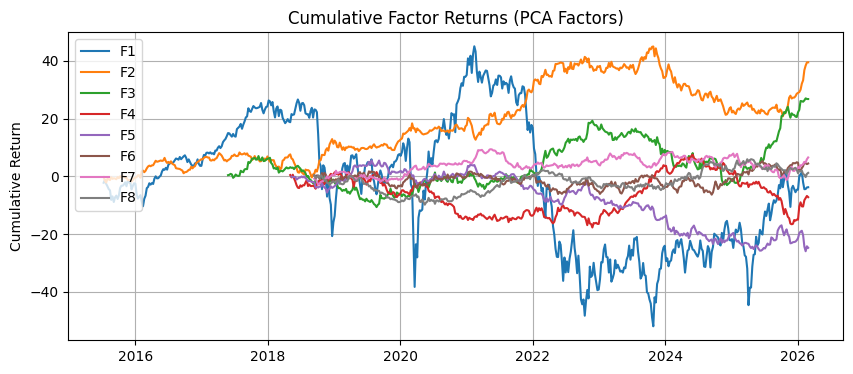

In [220]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    factor_ret.cumsum(), label=factor_ret.columns
)
ax.set_title("Cumulative Factor Returns (PCA Factors)")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid()
plt.show()

## loadings（ETF→因子）のヒートマップ

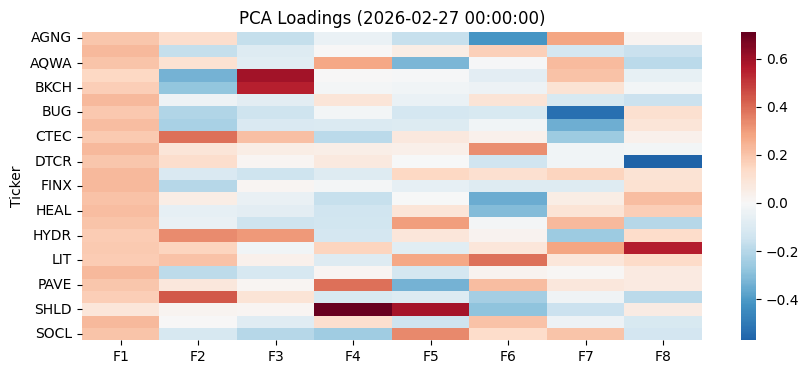

In [221]:
import seaborn as sns
latest_t = list(loadings_by_t.keys())[-1]
L = loadings_by_t[latest_t]
plt.figure(figsize=(10, 4))
sns.heatmap(
    L,
    cmap="RdBu_r",
    center=0
)
plt.title(f"PCA Loadings ({latest_t})")
plt.show()

## loadings の時間推移

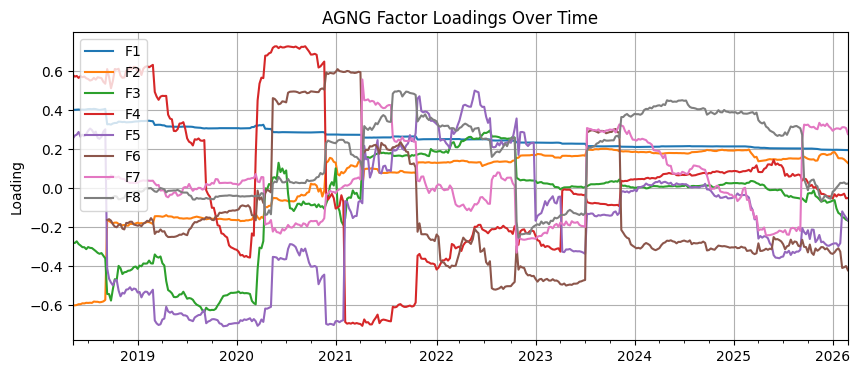

In [222]:
etf = CONFIG["tickers"][0]
series = []
for t, L in loadings_by_t.items():
    if etf in L.index:
        s = L.loc[etf]
        s.name = t
        series.append(s)

df = pd.DataFrame(series)
df.plot(figsize=(10, 4))
plt.title(f"{etf} Factor Loadings Over Time")
plt.ylabel("Loading")
plt.grid()
plt.show()

## 因子の寄与（どのETFが支配しているか）

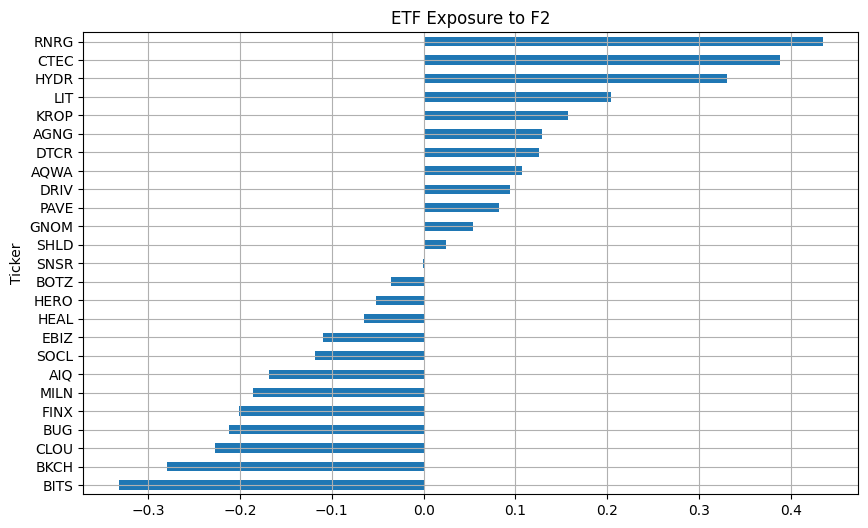

In [223]:
pc = "F2"
latest_t = list(loadings_by_t.keys())[-1]
L = loadings_by_t[latest_t]
L[pc].sort_values().plot.barh(figsize=(10, 6))
plt.title(f"ETF Exposure to {pc}")
plt.grid()
plt.show()

In [224]:
ret_p

Ticker,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
Date,,,,,,,,,,,,,,,,,,,,,
2010-07-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.036047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.036593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.060764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.012323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-30,-0.004314,-0.010284,0.002569,-0.076999,-0.086019,-0.011914,-0.036351,0.003844,-0.037348,-0.014171,...,0.007315,0.000574,-0.064214,-0.031838,-0.006849,0.002940,-0.021841,-0.012328,-0.032537,0.015527
2026-02-06,0.017168,-0.036367,0.024823,-0.136989,-0.116047,0.004287,-0.059029,0.004429,-0.064500,-0.019069,...,0.045649,0.034434,0.016297,-0.033432,0.077635,0.014296,-0.031632,0.031709,-0.078354,0.007482
2026-02-13,0.014189,-0.012580,0.021770,0.003268,0.021985,0.022946,0.035264,0.010360,0.017107,-0.020802,...,0.010646,0.047670,0.022647,-0.046434,0.007863,0.015773,-0.008921,0.024531,-0.039208,0.057798


## 因子説明力

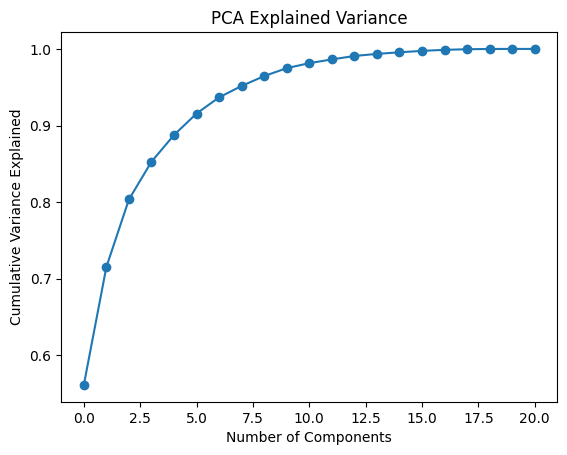

In [225]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(ret_p.dropna())
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.ylabel("Cumulative Variance Explained")
plt.xlabel("Number of Components")
plt.title("PCA Explained Variance")
plt.show()

## 因子リターン vs ETF

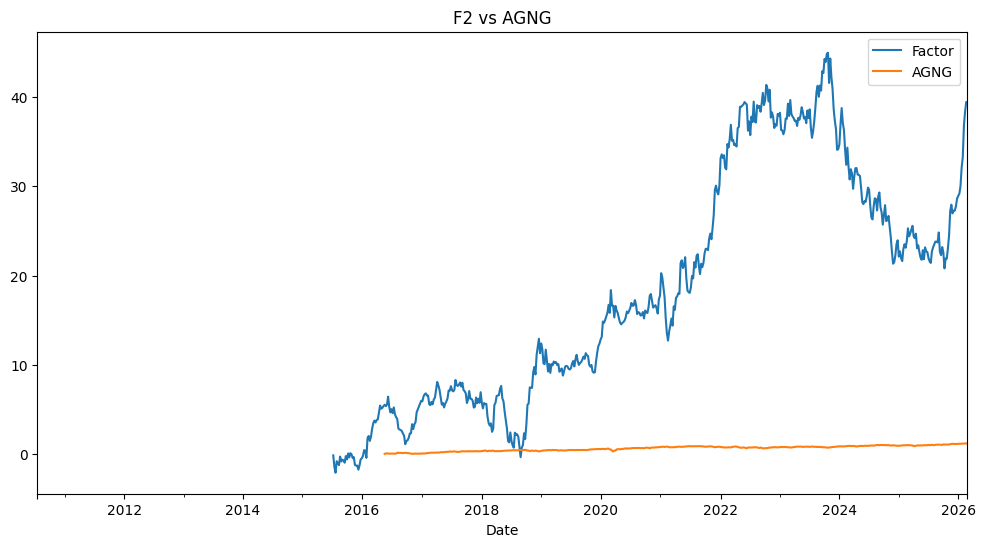

In [226]:
pc = "F2"
etf = CONFIG["tickers"][0]
fig, ax = plt.subplots(figsize=(12,6))
factor_ret[pc].cumsum().plot(ax=ax, label="Factor")
ret_p[etf].cumsum().plot(ax=ax, label=etf)
ax.legend()
ax.set_title(f"{pc} vs {etf}")
plt.show()

## Factor Breadth
どれだけ多くの因子が同時に上昇しているか
$$Breadth_t=\frac{1}{K}\sum_{k=1}^K 1(f_{k,t}\gt 0)$$

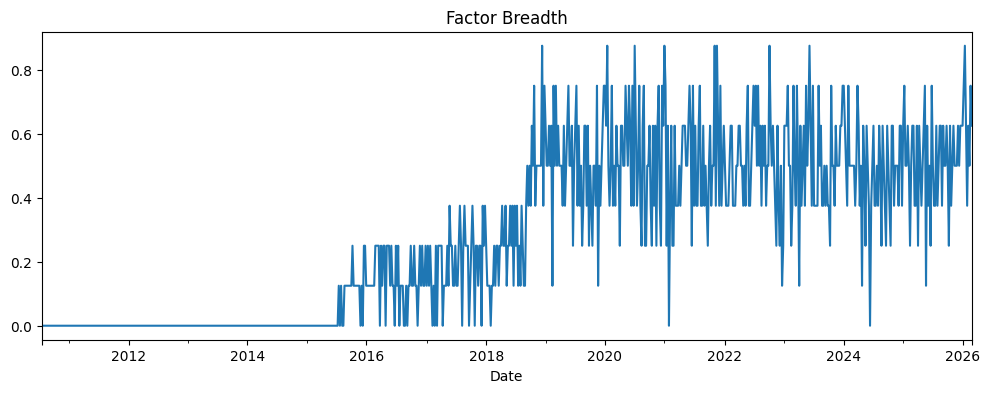

In [227]:
breadth = (factor_ret > 0).mean(axis=1)
breadth.plot(figsize=(12,4))
plt.title("Factor Breadth")
plt.show()

## Top Exposure ETF
PCA因子は
$$R=WF$$
$R$: ETF return
$F$: factor
$W$: loadings

各因子で $|W_{i,k}|$ が大きいETF

In [228]:
def label_factors(loadings_by_t, top_n=5):
    latest_t = list(loadings_by_t.keys())[-1]
    L = loadings_by_t[latest_t]
    labels = {}
    for f in L.columns:
        top = L[f].abs().sort_values(ascending=False).head(top_n)
        labels[f] = list(top.index)
    return labels
labels = label_factors(loadings_by_t)
labels

{'F1': ['BOTZ', 'AIQ', 'DRIV', 'MILN', 'FINX'],
 'F2': ['RNRG', 'CTEC', 'BITS', 'HYDR', 'BKCH'],
 'F3': ['BITS', 'BKCH', 'HYDR', 'CTEC', 'SOCL'],
 'F4': ['SHLD', 'PAVE', 'AQWA', 'SOCL', 'CTEC'],
 'F5': ['SHLD', 'SOCL', 'PAVE', 'AQWA', 'HERO'],
 'F6': ['AGNG', 'LIT', 'GNOM', 'DRIV', 'HEAL'],
 'F7': ['BUG', 'CLOU', 'AGNG', 'KROP', 'CTEC'],
 'F8': ['DTCR', 'KROP', 'GNOM', 'HERO', 'RNRG']}

## クラスタリング
loadingsをクラスタリング、ETFテーマごとまとまる

In [229]:
from sklearn.cluster import KMeans
latest_t = list(loadings_by_t.keys())[-1]
L = loadings_by_t[latest_t]
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(L)
cluster_df = L.copy()
cluster_df["cluster"] = clusters
cluster_df.sort_values("cluster")

,F1,F2,F3,F4,F5,F6,F7,F8,cluster
Ticker,,,,,,,,,
AGNG,0.194805,0.128775,-0.166457,-0.050887,-0.164398,-0.420867,0.277149,0.023451,0
HEAL,0.215081,-0.064626,-0.071934,-0.138156,0.093424,-0.309025,0.095607,0.170294,0
GNOM,0.205783,0.053512,-0.055039,-0.165101,-0.005669,-0.347017,0.049763,0.215807,0
PAVE,0.197753,0.081998,0.011302,0.385453,-0.334468,0.216303,0.081436,0.063093,1
MILN,0.227830,-0.185529,-0.120316,0.018215,-0.122142,0.028859,0.008427,0.059893,1
KROP,0.185691,0.157279,-0.024660,0.156645,-0.078068,0.085380,0.274753,0.558824,1
HERO,0.203021,-0.052269,-0.151084,-0.133503,0.296881,-0.015058,0.233159,-0.203744,1
SNSR,0.226836,-0.000268,-0.084730,0.116944,-0.141530,0.206481,-0.034225,-0.114975,1
EBIZ,0.226648,-0.109932,-0.145960,-0.091573,0.144397,0.113641,0.158025,0.100345,1


## 均等因子ポートフォリオ

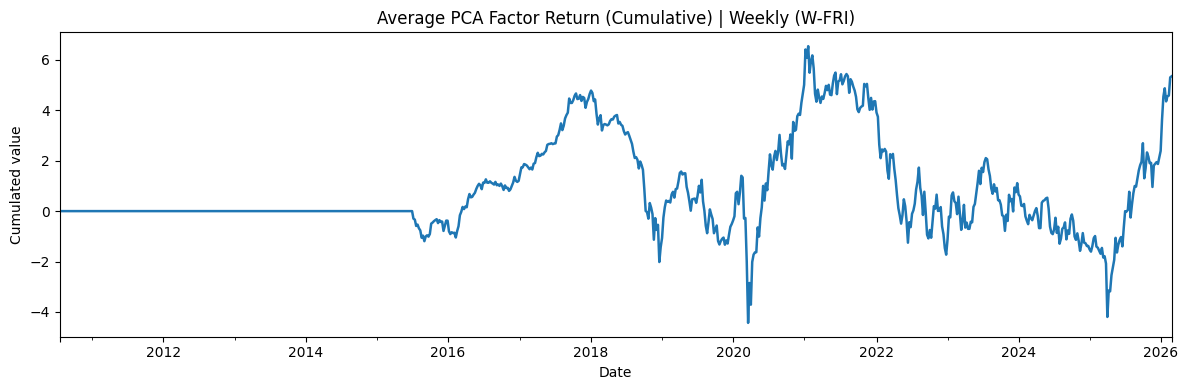

PCA eligibility count tail:


Date
2026-01-30    25
2026-02-06    25
2026-02-13    25
2026-02-20    25
2026-02-27    25
Freq: W-FRI, Name: eligible_count_pca, dtype: int64

In [230]:
fig, ax = plt.subplots(figsize=(12, 4))
((factor_ret.fillna(0).mean(axis=1)).cumsum()).plot(ax=ax, linewidth=1.8)
ax.set_title(f"Average PCA Factor Return (Cumulative) | {RUNTIME['frequency_label']}")
ax.set_ylabel('Cumulated value')
plt.tight_layout()
plt.show()
print('PCA eligibility count tail:')
display(elig_pca_count.tail())

In [231]:
def compute_factor_mom(factor_ret, lookbacks_periods, skip_periods, combine_weights_periods):
    # combine_weights を正規化（未正規化入力でも可）
    lookbacks = sorted(set(int(x) for x in lookbacks_periods))

    raw_w = {int(k): float(v) for k, v in combine_weights_periods.items() if int(k) in lookbacks}
    s = sum(raw_w.values())
    if s == 0:
        norm_w = {int(L): 1.0 / len(lookbacks) for L in lookbacks}
    else:
        norm_w = {int(L): raw_w.get(int(L), 0.0) / s for L in lookbacks}

    mom_parts = {}
    for L in lookbacks:
        L = int(L)
        # 短期lookbackは通常モメンタム、長期lookbackは skip を反映
        start_lag = 1
        if skip_periods > 0 and L > (skip_periods + 1):
            start_lag = skip_periods + 1

        lagged = [factor_ret.shift(j) for j in range(start_lag, L + 1)]
        mom_L = sum(lagged) if lagged else factor_ret * np.nan
        mom_parts[L] = mom_L

    mom_df = sum(norm_w[L] * mom_parts[L] for L in lookbacks)
    return mom_df, mom_parts, norm_w

factor_mom_raw, mom_parts, norm_cw = compute_factor_mom(
    factor_ret=factor_ret,
    lookbacks_periods=RUNTIME['lookbacks_periods'],
    skip_periods=RUNTIME['skip_periods'],
    combine_weights_periods=RUNTIME['combine_weights_periods'],
)

print('Runtime lookbacks(periods):', RUNTIME['lookbacks_periods'])
print('Runtime skip(periods):', RUNTIME['skip_periods'])
print('Normalized combine_weights(periods):', norm_cw)
print('Check sum(combine_weights_normalized)=', sum(norm_cw.values()))

Runtime lookbacks(periods): [4, 52]
Runtime skip(periods): 4
Normalized combine_weights(periods): {4: 0.5, 52: 0.5}
Check sum(combine_weights_normalized)= 1.0


## 指定PC除外

In [232]:

def resolve_excluded_factor_labels(exclude_pcs, factor_columns):
    labels = [c for c in factor_columns if isinstance(c, str) and c.startswith('F') and c[1:].isdigit()]
    valid_nums = {int(c[1:]) for c in labels}

    excluded = set()
    invalid = []
    for raw in (exclude_pcs or []):
        try:
            n = int(raw)
        except (TypeError, ValueError):
            invalid.append(raw)
            continue

        if n in valid_nums:
            excluded.add(f'F{n}')
        else:
            invalid.append(raw)

    if invalid:
        print(f"[WARN] invalid exclude_pcs ignored: {invalid}")

    return excluded


def apply_factor_exclusion(factor_mom, excluded_labels):
    factor_mom_ex = factor_mom.copy()
    cols = [c for c in excluded_labels if c in factor_mom_ex.columns]
    if cols:
        factor_mom_ex.loc[:, cols] = np.nan
    return factor_mom_ex

excluded_factor_labels = resolve_excluded_factor_labels(CONFIG.get('exclude_pcs', []), factor_mom_raw.columns)
factor_mom = apply_factor_exclusion(factor_mom_raw, excluded_factor_labels)

## 異なる期間のモメンタム加重平均
mom_parts（lookbackごとのモメンタム）
norm_cw（合成ウェイト）
factor_mom（最終モメンタム）

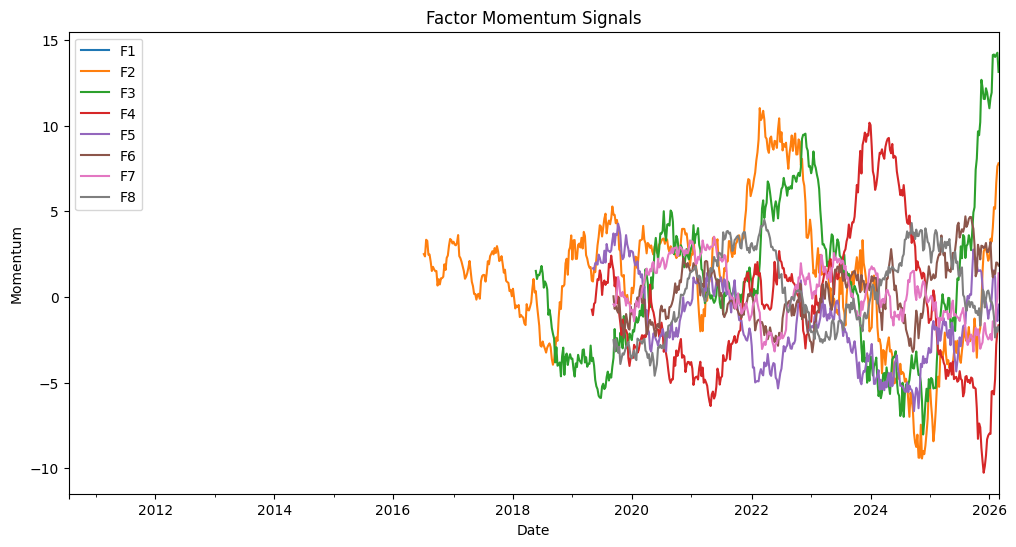

In [233]:
fig, ax = plt.subplots(figsize=(12,6))
factor_mom.plot(ax=ax)
ax.set_title("Factor Momentum Signals")
ax.set_ylabel("Momentum")
plt.show()

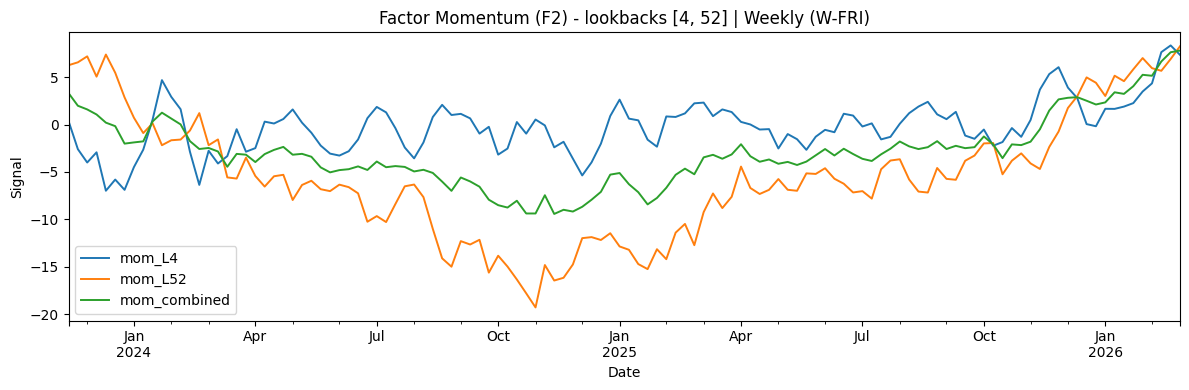

In [234]:
lookbacks_sorted = sorted(mom_parts.keys())
sample_factor = 'F2'
plot_dict = {f"mom_L{lb}": mom_parts[lb][sample_factor] for lb in lookbacks_sorted}
plot_dict['mom_combined'] = factor_mom[sample_factor]
plot_df = pd.DataFrame(plot_dict).dropna()

fig, ax = plt.subplots(figsize=(12, 4))
plot_df.tail(120).plot(ax=ax, linewidth=1.4)
ax.set_title(f"Factor Momentum ({sample_factor}) - lookbacks {lookbacks_sorted} | {RUNTIME['frequency_label']}")
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()

## Factor Momentum シグナル（factor_mom）を「因子ポートフォリオのウェイト」へ変換する関数
1. top_m: 上位m個
2. rank: モメンタム順位で重みつけ
3. sign: モメンタム符号が正のもの

In [235]:
def normalize_long_only(w):
    w = w.clip(lower=0.0)
    total = w.sum()
    if total > 0:
        return w / total
    return w * 0.0


def normalize_ls(w):
    gross = w.abs().sum()
    if gross > 0:
        return w / gross
    return w * 0.0

def allocate_factor_weights(mom_t, method='top_m', top_m=3, long_only=True):
    x = mom_t.dropna().copy()
    if len(x) == 0:
        return pd.Series(index=mom_t.index, data=0.0)

    if method == 'top_m':
        winners = x.nlargest(min(top_m, len(x)))
        w = pd.Series(0.0, index=x.index)
        if long_only:
            winners = winners[winners > 0]
            if len(winners) > 0:
                w.loc[winners.index] = 1.0 / len(winners)
        else:
            w.loc[winners.index] = 1.0 / len(winners)

    elif method == 'rank':
        r = x.rank(method='average', ascending=True)
        w = r - r.min()
        if long_only:
            w = normalize_long_only(w)
        else:
            w = normalize_ls(w - w.mean())

    elif method == 'sign':
        w = np.sign(x)
        if long_only:
            w = normalize_long_only(w)
        else:
            w = normalize_ls(w)

    else:
        raise ValueError(f'Unknown factor_weighting method: {method}')

    # full factor indexへ戻す
    out = pd.Series(0.0, index=mom_t.index)
    out.loc[w.index] = w.values

    if long_only:
        out = normalize_long_only(out)
    else:
        out = normalize_ls(out)

    return out

# factor_weighting 3方式の比較（同一期）
latest_t = factor_mom.dropna(how='all').index[-1]
w_top = allocate_factor_weights(factor_mom.loc[latest_t], method='top_m', top_m=CONFIG['top_m_factors'], long_only=CONFIG['long_only'])
w_rank = allocate_factor_weights(factor_mom.loc[latest_t], method='rank', top_m=CONFIG['top_m_factors'], long_only=CONFIG['long_only'])
w_sign = allocate_factor_weights(factor_mom.loc[latest_t], method='sign', top_m=CONFIG['top_m_factors'], long_only=CONFIG['long_only'])

print(f'Factor allocation comparison at {latest_t.date()}')
display(pd.DataFrame({'top_m': w_top, 'rank': w_rank, 'sign': w_sign}).T)

Factor allocation comparison at 2026-02-27


,F1,F2,F3,F4,F5,F6,F7,F8
top_m,0.0,0.333333,0.333333,0.000000,0.000000,0.333333,0.000000,0.0
rank,0.0,0.238095,0.285714,0.047619,0.095238,0.190476,0.142857,0.0
sign,0.0,0.250000,0.250000,0.000000,0.000000,0.250000,0.250000,0.0


## PCA因子ポート（因子ウェイト）を「実際に買えるETFのウェイト」に変換する写像
$$w_t^{ETF} \propto W_t w_t^{factor}$$
右辺を実行し合計１になるよう圧縮

### regression
過去reression期間を用いてETFごとに
$$r_{i,\tau}=\alpha_i+\beta_i f_\tau + \epsilon_{i,\tau}$$
を最小二乗法で推定。
$$w_t^{ETF} \propto \beta_i w_t^{factor}$$
既知因子を加えて回帰する。

In [236]:
def apply_weight_cap(w, cap=None):
    if cap is None:
        return w
    w = w.clip(upper=cap)
    if (w >= 0).all():
        return normalize_long_only(w)
    return normalize_ls(w)

## 7) S2-L: mapping(loadings) + backtest + plots

def map_loadings_to_etf(loadings_t, w_factor, elig_mask_t, cap=None):
    all_assets = elig_mask_t.index

    fac = loadings_t.columns.intersection(w_factor.index)
    if len(fac) == 0:
        return pd.Series(0.0, index=all_assets)

    raw = loadings_t[fac].dot(w_factor[fac])

    w = pd.Series(0.0, index=all_assets)
    w.loc[raw.index] = raw.values
    w.loc[~elig_mask_t] = 0.0

    if CONFIG['long_only']:
        w = normalize_long_only(w)
    else:
        w = normalize_ls(w)

    w = apply_weight_cap(w, cap=cap)
    return w

all_tickers = ret_p.columns.tolist()
eligibility_mask_by_t = elig_pca_count.attrs['eligibility_mask_by_t']

weights_s2l_dict = {}
skipped_s2l = 0

for t in sorted(loadings_by_t.keys()):
    if t not in factor_mom.index:
        continue
    mom_t = factor_mom.loc[t]
    if mom_t.isna().all():
        skipped_s2l += 1
        continue

    w_factor_t = allocate_factor_weights(
        mom_t,
        method=CONFIG['factor_weighting'],
        top_m=CONFIG['top_m_factors'],
        long_only=CONFIG['long_only'],
    )

    elig_t = eligibility_mask_by_t.get(t, pd.Series(False, index=all_tickers)).reindex(all_tickers).fillna(False)
    w_etf_t = map_loadings_to_etf(loadings_by_t[t], w_factor_t, elig_t, cap=CONFIG['weight_cap'])

    if np.isclose(w_etf_t.sum(), 0.0):
        skipped_s2l += 1
        continue

    weights_s2l_dict[t] = w_etf_t

weights_s2l = pd.DataFrame.from_dict(weights_s2l_dict, orient='index').reindex(columns=all_tickers).fillna(0.0).sort_index()


In [237]:

def compute_turnover(w_t, w_prev):
    return 0.5 * np.abs(w_t - w_prev).sum()


def calc_drawdown(equity):
    peak = equity.cummax()
    return equity / peak - 1.0


def next_period_index(idx, t):
    if t not in idx:
        return None
    pos = idx.get_loc(t)
    if isinstance(pos, slice):
        pos = pos.stop - 1
    elif isinstance(pos, np.ndarray):
        pos = int(np.where(pos)[0][-1])
    nxt = int(pos) + 1
    if nxt >= len(idx):
        return None
    return idx[nxt]


In [238]:

def run_backtest(weights_by_t, ret_p, cost_bps):
    if weights_by_t.empty:
        idx = pd.DatetimeIndex([], name='period')
        empty = pd.Series(index=idx, dtype=float)
        return empty.copy(), empty.copy(), empty.copy(), empty.copy(), empty.copy()

    weights_by_t = weights_by_t.sort_index().fillna(0.0)
    tickers = list(weights_by_t.columns)

    decision_periods = []
    applied_periods = []
    gross_vals = []
    net_vals = []
    turn_vals = []

    w_prev = pd.Series(0.0, index=tickers)

    for t, w_t in weights_by_t.iterrows():
        apply_t = next_period_index(ret_p.index, t)
        if apply_t is None:
            continue

        r_next = ret_p.loc[apply_t].reindex(tickers).fillna(0.0)
        w_t = w_t.reindex(tickers).fillna(0.0)

        turnover = compute_turnover(w_t, w_prev)
        gross = float(np.dot(w_t.values, r_next.values))
        net = gross - turnover * (cost_bps / 10000.0)

        decision_periods.append(t)
        applied_periods.append(apply_t)
        gross_vals.append(gross)
        net_vals.append(net)
        turn_vals.append(turnover)

        w_prev = w_t

    idx = pd.DatetimeIndex(applied_periods, name='period')
    gross_s = pd.Series(gross_vals, index=idx, name='gross')
    net_s = pd.Series(net_vals, index=idx, name='net')
    turnover_s = pd.Series(turn_vals, index=idx, name='turnover')

    equity = (1.0 + net_s).cumprod().rename('equity')
    dd = calc_drawdown(equity).rename('drawdown')

    decision_idx = pd.DatetimeIndex(decision_periods, name='decision_period')
    for s in (gross_s, net_s, turnover_s, equity, dd):
        s.attrs['decision_periods'] = decision_idx

    return gross_s, net_s, turnover_s, equity, dd


def build_eqw(eligibility_by_t, ret_p, cost_bps):
    tickers = list(eligibility_by_t.columns)
    rows = {}
    for t, elig in eligibility_by_t.sort_index().iterrows():
        elig = elig.reindex(tickers).fillna(False)
        w = pd.Series(0.0, index=tickers)
        n = int(elig.sum())
        if n > 0:
            w.loc[elig.index[elig.values]] = 1.0 / n
        rows[t] = w

    weights_eqw = pd.DataFrame.from_dict(rows, orient='index').reindex(columns=tickers).fillna(0.0)
    _, eqw_net, eqw_turnover, eqw_equity, eqw_dd = run_backtest(weights_eqw, ret_p, cost_bps)

    return eqw_net, eqw_turnover, eqw_equity, eqw_dd


def plot_equity_dd(equity_map, dd_map, title_prefix='Strategy Comparison'):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    for name, s in equity_map.items():
        axes[0].plot(s.index, s.values, label=name, linewidth=2)
    axes[0].set_title(f'{title_prefix} - Equity Curve')
    axes[0].set_ylabel('Equity (start=1)')
    axes[0].legend()

    for name, s in dd_map.items():
        axes[1].plot(s.index, s.values, label=name, linewidth=1.8)
    axes[1].set_title(f'{title_prefix} - Drawdown Curve')
    axes[1].set_ylabel('Drawdown')
    axes[1].set_xlabel(f"Period ({RUNTIME['rule']})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

S2-L decision periods: 474 (skipped=82)
S2-L net return periods: 473


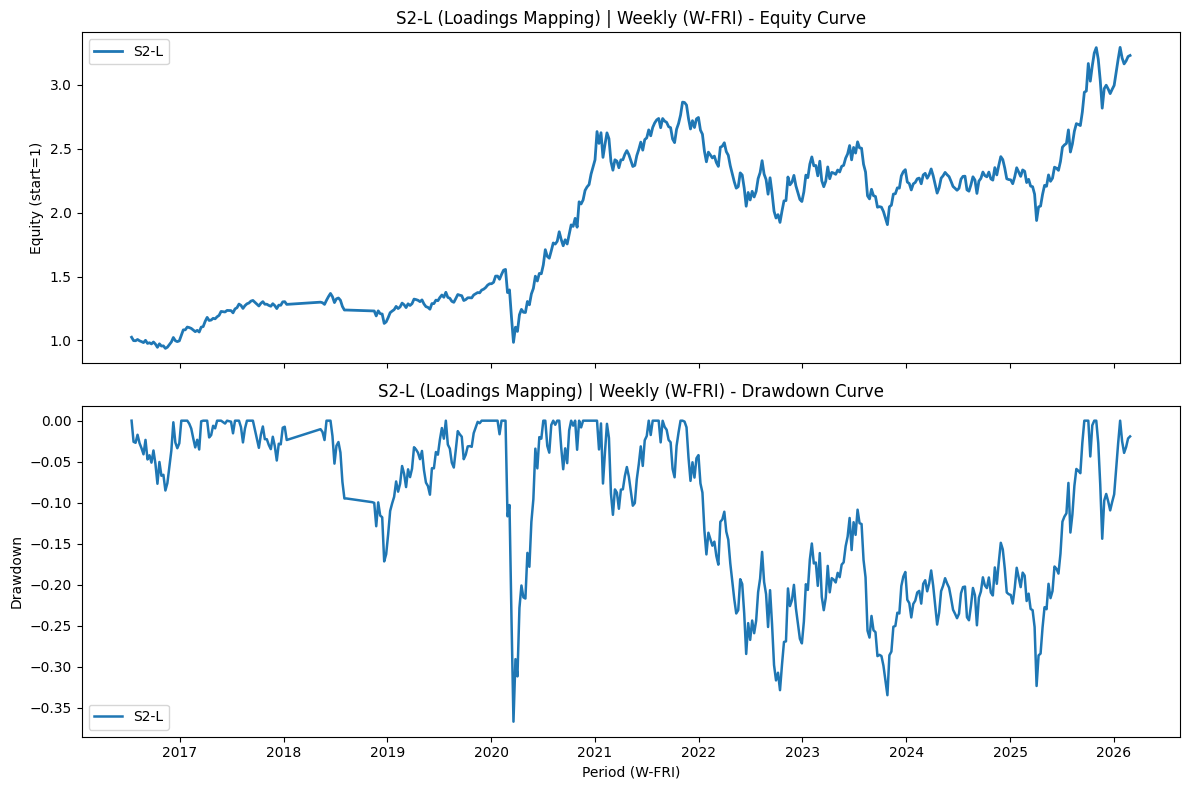

In [239]:

gross_s2l, net_s2l, turnover_s2l, equity_s2l, dd_s2l = run_backtest(weights_s2l, ret_p, CONFIG['cost_bps'])

print(f'S2-L decision periods: {len(weights_s2l)} (skipped={skipped_s2l})')
print(f'S2-L net return periods: {len(net_s2l)}')

plot_equity_dd(
    equity_map={'S2-L': equity_s2l},
    dd_map={'S2-L': dd_s2l},
    title_prefix=f"S2-L (Loadings Mapping) | {RUNTIME['frequency_label']}"
)


S2-R decision periods: 287 (skipped=528)
S2-R net return periods: 286


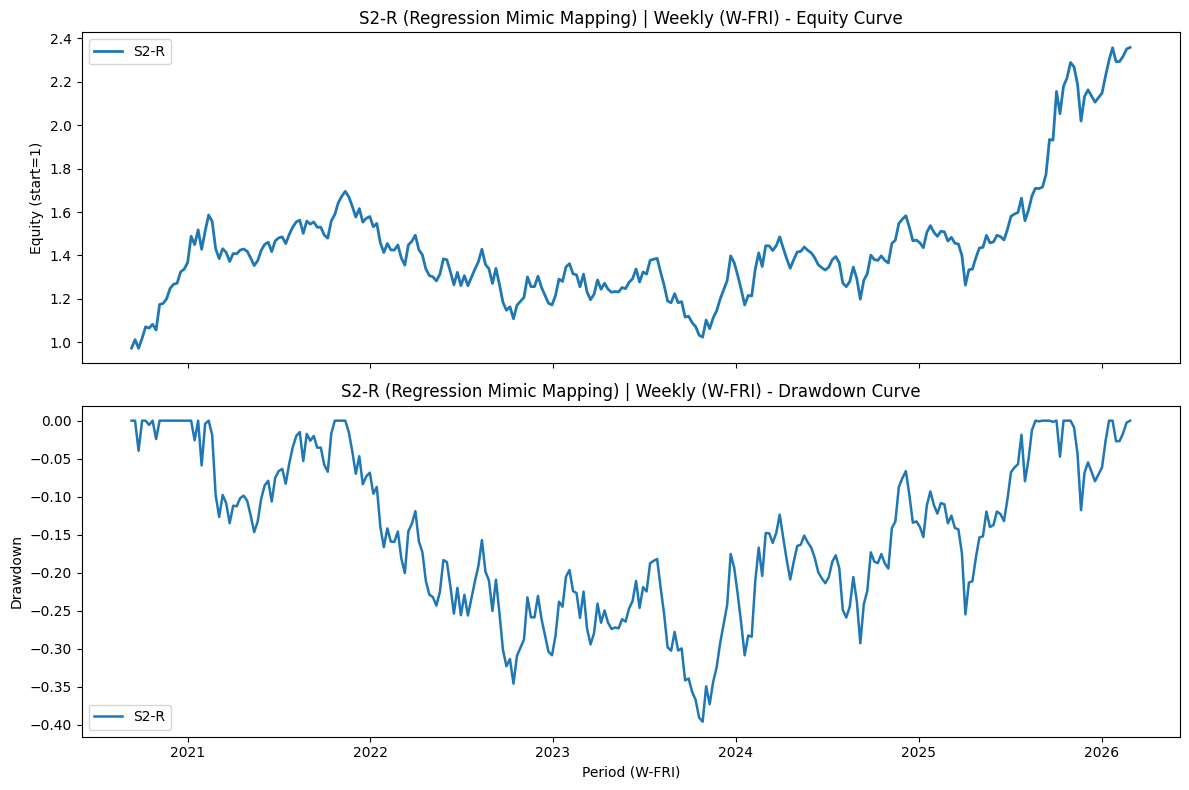

,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
2026-01-30,0.039803,0.000000,0.000000,0.0,0.0,0.015722,0.0,0.0,0.0,0.195231,...,0.0,0.006904,0.210388,0.0,0.001860,0.097961,0.023907,0.026453,0.0,0.0
2026-02-06,0.000000,0.006496,0.028839,0.0,0.0,0.043997,0.0,0.0,0.0,0.133432,...,0.0,0.114815,0.134689,0.0,0.104897,0.044433,0.000000,0.076171,0.0,0.0
2026-02-13,0.000000,0.006125,0.029229,0.0,0.0,0.044406,0.0,0.0,0.0,0.129003,...,0.0,0.117516,0.134963,0.0,0.105002,0.042680,0.000000,0.078240,0.0,0.0
2026-02-20,0.000000,0.005661,0.028982,0.0,0.0,0.044677,0.0,0.0,0.0,0.129080,...,0.0,0.117698,0.133101,0.0,0.106478,0.041863,0.000000,0.078259,0.0,0.0
2026-02-27,0.000000,0.005665,0.028986,0.0,0.0,0.044675,0.0,0.0,0.0,0.129006,...,0.0,0.117706,0.133144,0.0,0.106502,0.041827,0.000000,0.078252,0.0,0.0


In [240]:
## 8) S2-R: mapping(regression mimic) + backtest + plots

def estimate_regression_betas(ret_p, factor_ret, t, window_periods=60, min_obs=24):
    if t not in ret_p.index:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    pos = ret_p.index.get_loc(t)
    if pos < window_periods - 1:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    win_idx = ret_p.index[pos - window_periods + 1 : pos + 1]
    X_all = factor_ret.reindex(win_idx)

    valid_factor_cols = [c for c in factor_ret.columns if pd.notna(factor_ret.loc[t, c])]
    if len(valid_factor_cols) == 0:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    X_all = X_all[valid_factor_cols]

    beta_rows = {}
    for tk in ret_p.columns:
        if pd.isna(ret_p.loc[t, tk]):
            continue
        y = ret_p.loc[win_idx, tk]
        reg_df = pd.concat([y.rename('y'), X_all], axis=1).dropna()

        need_obs = max(min_obs, len(valid_factor_cols) + 1)
        if len(reg_df) < need_obs:
            continue

        yv = reg_df['y'].values
        xv = reg_df[valid_factor_cols].values
        xv = np.column_stack([np.ones(len(xv)), xv])

        coef = np.linalg.lstsq(xv, yv, rcond=None)[0]
        beta_rows[tk] = coef[1:]

    if not beta_rows:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    beta_mat = pd.DataFrame.from_dict(beta_rows, orient='index', columns=valid_factor_cols)
    elig = pd.Series(False, index=ret_p.columns)
    elig.loc[beta_mat.index] = True

    return beta_mat, elig


def map_regression_to_etf(beta_t, w_factor, elig_mask_t, cap=None):
    all_assets = elig_mask_t.index
    if beta_t.empty:
        return pd.Series(0.0, index=all_assets)

    fac = beta_t.columns.intersection(w_factor.index)
    if len(fac) == 0:
        return pd.Series(0.0, index=all_assets)

    raw = beta_t[fac].dot(w_factor[fac])

    w = pd.Series(0.0, index=all_assets)
    w.loc[raw.index] = raw.values
    w.loc[~elig_mask_t] = 0.0

    if CONFIG['long_only']:
        w = normalize_long_only(w)
    else:
        w = normalize_ls(w)

    w = apply_weight_cap(w, cap=cap)
    return w


weights_s2r_dict = {}
elig_reg_count = pd.Series(index=ret_p.index, dtype=float)
skipped_s2r = 0

for t in sorted(factor_mom.index):
    if t not in ret_p.index:
        continue

    mom_t = factor_mom.loc[t]
    if mom_t.isna().all():
        skipped_s2r += 1
        continue

    beta_t, elig_t = estimate_regression_betas(
        ret_p=ret_p,
        factor_ret=factor_ret,
        t=t,
        window_periods=RUNTIME['reg_window'],
        min_obs=RUNTIME['min_obs'],
    )

    elig_reg_count.loc[t] = int(elig_t.sum())
    if beta_t.empty:
        skipped_s2r += 1
        continue

    w_factor_t = allocate_factor_weights(
        mom_t,
        method=CONFIG['factor_weighting'],
        top_m=CONFIG['top_m_factors'],
        long_only=CONFIG['long_only'],
    )

    w_etf_t = map_regression_to_etf(beta_t, w_factor_t, elig_t, cap=CONFIG['weight_cap'])
    if np.isclose(w_etf_t.sum(), 0.0):
        skipped_s2r += 1
        continue

    weights_s2r_dict[t] = w_etf_t

weights_s2r = pd.DataFrame.from_dict(weights_s2r_dict, orient='index').reindex(columns=all_tickers).fillna(0.0).sort_index()
elig_reg_count = elig_reg_count.fillna(0).astype(int).rename('eligible_count_reg')

gross_s2r, net_s2r, turnover_s2r, equity_s2r, dd_s2r = run_backtest(weights_s2r, ret_p, CONFIG['cost_bps'])

print(f'S2-R decision periods: {len(weights_s2r)} (skipped={skipped_s2r})')
print(f'S2-R net return periods: {len(net_s2r)}')

plot_equity_dd(
    equity_map={'S2-R': equity_s2r},
    dd_map={'S2-R': dd_s2r},
    title_prefix=f"S2-R (Regression Mimic Mapping) | {RUNTIME['frequency_label']}"
)

weights_s2r.tail()

Common comparison window: 2020-09-11 -> 2026-02-27 (286 periods)


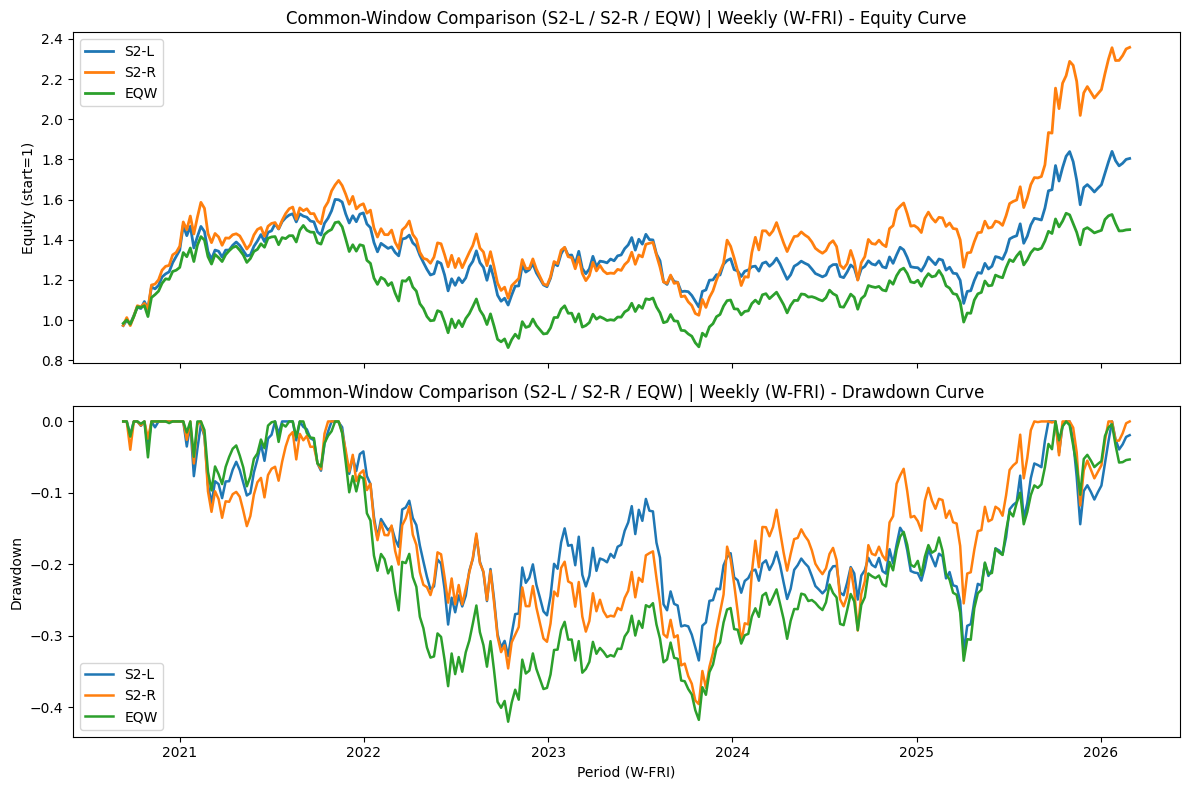

In [241]:
## 9) Compare (S2-L vs S2-R vs EQW) equity & drawdown

# EQW eligibility: PCAの時点tで投資候補になったETFを採用
eligibility_eqw = pd.DataFrame(
    {t: m.reindex(all_tickers).fillna(False) for t, m in eligibility_mask_by_t.items()}
).T.sort_index().astype(bool)
elig_eqw_count = eligibility_eqw.sum(axis=1).rename('eligible_count_eqw')

eqw_net, eqw_turnover, eqw_equity, eqw_dd = build_eqw(eligibility_eqw, ret_p, CONFIG['cost_bps'])

common_idx = net_s2l.index.intersection(net_s2r.index).intersection(eqw_net.index)
if len(common_idx) == 0:
    raise ValueError('No common comparison period among S2-L, S2-R, EQW.')

common_start = common_idx.min()
common_end = common_idx.max()
print(f'Common comparison window: {common_start.date()} -> {common_end.date()} ({len(common_idx)} periods)')

net_s2l_c = net_s2l.reindex(common_idx)
net_s2r_c = net_s2r.reindex(common_idx)
eqw_net_c = eqw_net.reindex(common_idx)

turn_s2l_c = turnover_s2l.reindex(common_idx)
turn_s2r_c = turnover_s2r.reindex(common_idx)
eqw_turn_c = eqw_turnover.reindex(common_idx)

equity_s2l_c = (1 + net_s2l_c).cumprod()
equity_s2r_c = (1 + net_s2r_c).cumprod()
eqw_equity_c = (1 + eqw_net_c).cumprod()

dd_s2l_c = calc_drawdown(equity_s2l_c)
dd_s2r_c = calc_drawdown(equity_s2r_c)
eqw_dd_c = calc_drawdown(eqw_equity_c)

plot_equity_dd(
    equity_map={'S2-L': equity_s2l_c, 'S2-R': equity_s2r_c, 'EQW': eqw_equity_c},
    dd_map={'S2-L': dd_s2l_c, 'S2-R': dd_s2r_c, 'EQW': eqw_dd_c},
    title_prefix=f"Common-Window Comparison (S2-L / S2-R / EQW) | {RUNTIME['frequency_label']}"
)

In [242]:


def calc_metrics(net_ret, turnover, periods_per_year):
    r = net_ret.dropna()
    if len(r) == 0:
        return pd.Series({'CAGR': np.nan, 'Vol': np.nan, 'Sharpe': np.nan, 'MDD': np.nan, 'Turnover': np.nan, 'Hit': np.nan})

    years = len(r) / float(periods_per_year)
    cagr = (1.0 + r).prod() ** (1.0 / years) - 1.0 if years > 0 else np.nan
    vol = r.std(ddof=0) * np.sqrt(periods_per_year)
    sharpe = (r.mean() / r.std(ddof=0) * np.sqrt(periods_per_year)) if r.std(ddof=0) > 0 else np.nan

    equity = (1.0 + r).cumprod()
    mdd = calc_drawdown(equity).min()
    to = turnover.reindex(r.index).mean()
    hit = (r > 0).mean()

    return pd.Series({'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe, 'MDD': mdd, 'Turnover': to, 'Hit': hit})



## 10) Metrics table (CAGR/Vol/Sharpe/MDD/Turnover/Hit)

metrics = pd.DataFrame({
    'S2-L': calc_metrics(net_s2l_c, turn_s2l_c, RUNTIME['periods_per_year']),
    'S2-R': calc_metrics(net_s2r_c, turn_s2r_c, RUNTIME['periods_per_year']),
    'EQW': calc_metrics(eqw_net_c, eqw_turn_c, RUNTIME['periods_per_year']),
}).T

print('Performance metrics on common window:')
display(metrics)

# basic sanity checks
assert np.isfinite(metrics[['CAGR','Vol','Sharpe','MDD','Turnover','Hit']].values).all(), 'Metrics contain NaN/inf.'
print('Metrics sanity check passed.')

Performance metrics on common window:


,CAGR,Vol,Sharpe,MDD,Turnover,Hit
S2-L,0.113316,0.225876,0.588568,-0.334720,0.122119,0.520979
S2-R,0.168788,0.260140,0.729698,-0.395964,0.103925,0.538462
EQW,0.069945,0.222041,0.415403,-0.420529,0.002737,0.517483


Metrics sanity check passed.


## 1) 参照論文URLと実装要点メモ

- Factor Momentum Everywhere (AQR WP)  
  <https://www.aqr.com/Insights/Research/Working-Paper/Factor-Momentum-Everywhere>
- Factor Momentum (RFS, 2023)  
  <https://academic.oup.com/rfs/article-abstract/36/8/3034/6988043>
- Factor Momentum and the Momentum Factor (NBER WP 25551)  
  <https://www.nber.org/system/files/working_papers/w25551/w25551.pdf>

**実装要点（本Notebook）**
- 因子は Rolling PCA（実効窓: `rebalance` に応じて自動換算）で各期再推定。
- 因子モメンタムは `lookback=1` と `lookback=12(12-1)` を月次意味で指定し、周波数に応じて期間換算。
- 因子配分は `top_m` をデフォルト実装（`rank`,`sign` も関数で切替可）。
- ETF写像は S2-L（loadings）と S2-R（regression mimic）を両方バックテスト。
- 期末で重み決定し、次期リターンへ適用（`w_t -> r_{t+1}`）。
- コスト控除は `turnover = 0.5 * sum(|w_t - w_{t-1}|)`、`net = gross - turnover * (cost_bps/10000)`。
- 比較は S2-L / S2-R / EQW を共通期間で実施。